# Notebook 1: Bayesian Optimization on Alanine Dipeptide


## **IMPORTANT**
Before you run this notebook, make sure you have downloaded the whole "HRSMC_ML" folder and added it to your own Drive. Then, continue from there and use Google Collab.

Welcome! In this notebook we use **Bayesian Optimization (BO)** to study the free energy landscape of **alanine dipeptide**, a small molecule that is a standard benchmark in computational chemistry.

### What you will learn


*   How to build a Gaussian Process (GP) surrogate of sparse simulation data
*   How kernel choice (RBF vs. Matérn) and lengthscale affect the GP fit, from overly wiggly to over-smoothed
*   How Bayesian Optimization uses Expected Improvement (EI), Probability of Improvement (PI), and Lower Confidence Bound (LCB) acquisition functions to find the gradient zero crossings with as few simulation queries as possible
* How the exploration-exploitation trade-off (controlled by xi and kappa) determines which zero crossing gets found and how many queries are "wasted"


We have two goals in this tutorial:
1. **Learn the free-energy gradient**: use a GP to build a surrogate model of the free-energy gradient from sparse observations. Here, we get familliar with all the hyperparamaters of the GPs.
2. **Find the free energy minimum**: use BO to efficiently to find where the gradient is zero (= minima/maxima of the free energy surface)

---

## Background: alanine dipeptide

Alanine dipeptide (Ace-Ala-Nme) is a small peptide with two backbone
dihedral angles: **φ** (phi) and **ψ** (psi). Despite its simplicity,
it has a rich conformational landscape and is widely used to benchmark
enhanced sampling methods. In this tutorial we focus on φ only, but
the method extends naturally to 2D, which we will see in the second notebook. Below you see the molecule with its dihedrals, the free energy landscape in 1D ($\phi$) and in 2D ($\phi,\psi$).

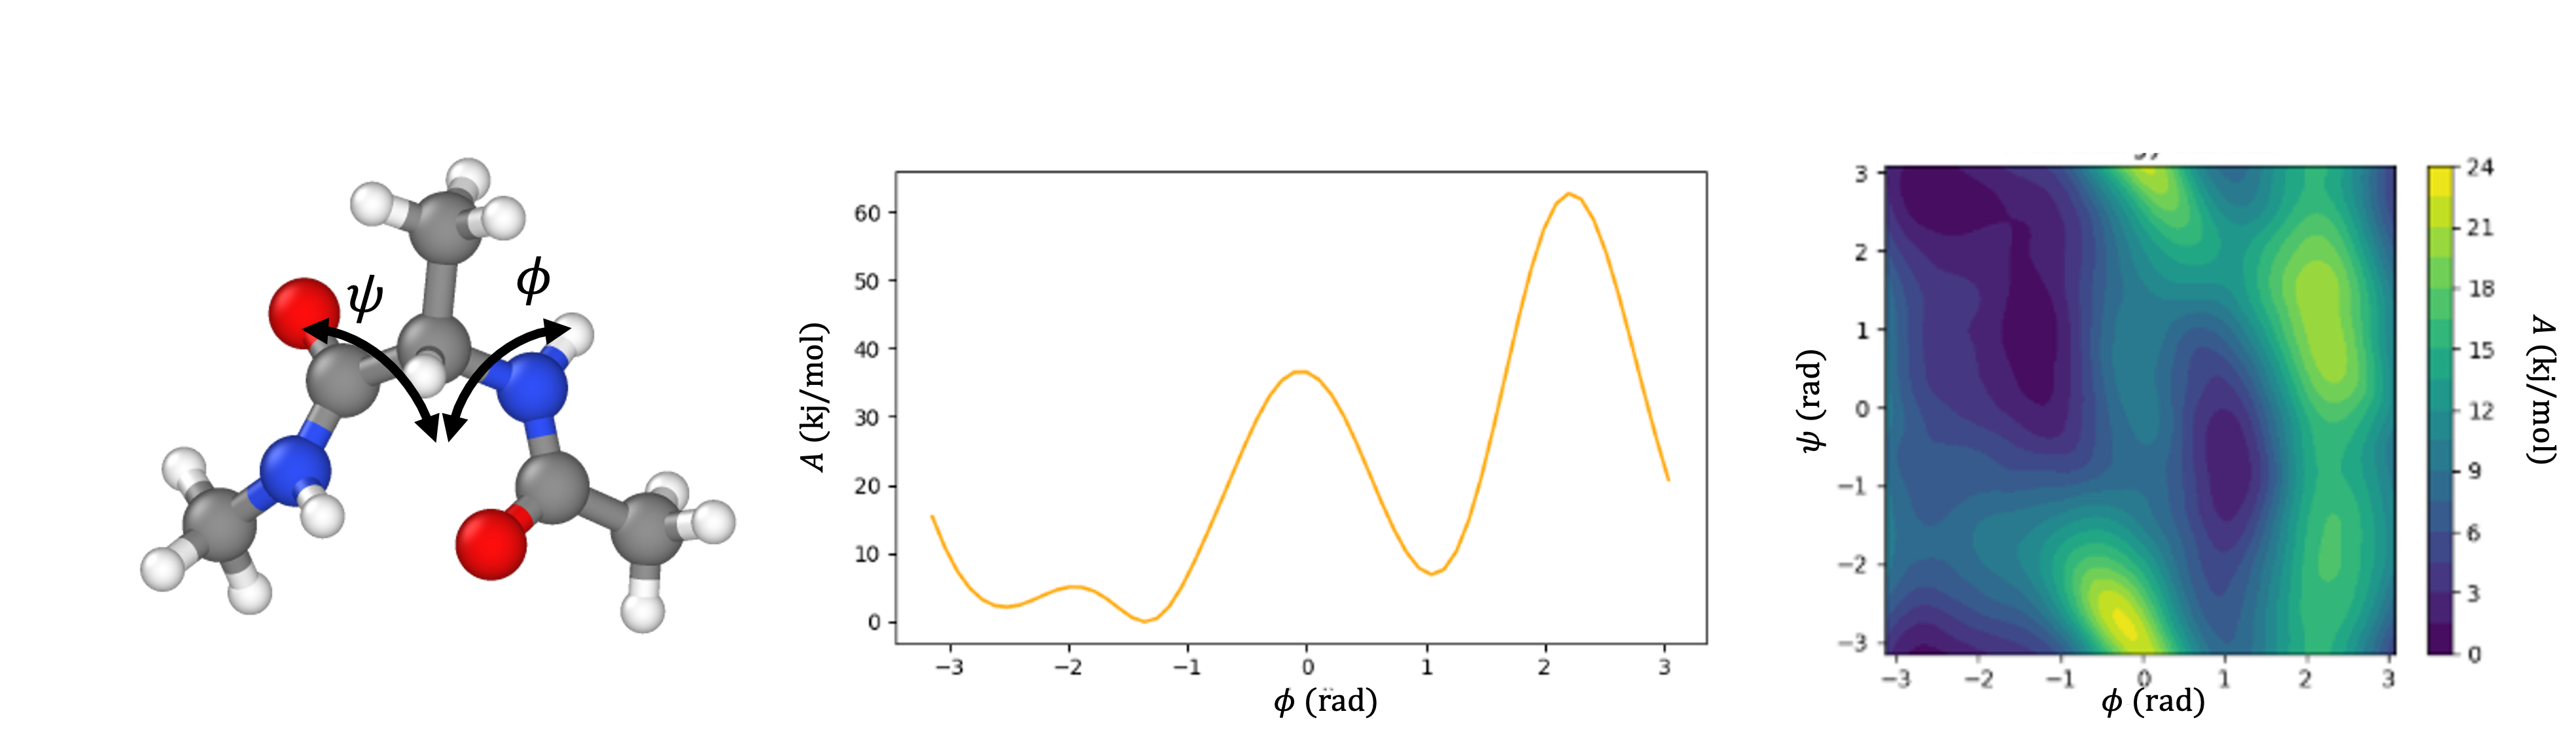



The **free energy surface** (FES) A(φ) tells us how stable each conformation is:
- A **minimum** in A(φ) → stable state (the system spends a lot of time here)
- A **maximum** in A(φ) → unstable state (transition region)

### How do we compute A(φ)?

Computing A(φ) from plain Molecular Dynamics (MD) is hard because the system rarely visits high free-energy regions. Instead, we use **Umbrella Sampling (US)**: we run many short simulations, each restrained to a different φ value by a harmonic bias. You can think about this bias as a simulated optical tweezer. The bias $U_\text{bias}(\phi)$  is defined as follows:

$$U_\text{bias}(\phi) = \frac{k}{2}(\phi - \phi_0)^2.$$

Here, $\kappa$ is the force constant, and $\phi_0$ is the position of the bias.

### From bias to mean force

Because the bias is harmonic, the mean force at φ₀ is easy to measure:

$$\bar{f}(\phi_0) = \left\langle \frac{\partial U_\text{bias}}{\partial \phi} \right\rangle = k \left( \bar{\phi} - \phi_0 \right).$$

In other words, we measure the average displacement of φ from φ₀ , multiply by k and done. This works as long as the distribution of the $\phi$ values is unimodal.
Now we can use $\frac{\partial A(\phi)}{\partial \phi}|_{\phi_0}\approx
     - \bar{f}(\phi_0) $ to reconstruct the free-energy landscape. In other words, once we have f(φ) = - dA/dφ at enough points, i.e. we have run enough simulations, we recover A(φ) by integration over the $\phi$ space:

$$A(\phi) \approx \int_{-\pi}^{\pi} - f(\phi') \, d\phi'.$$

### The problem and our solution

Each simulation window gives us f(φ) at **one** value of φ. Covering the full range [-π, π] with many windows is expensive. Of course, this problem becomes even more pronounced in more dimensions. In this first tutorial, we will focus on the derivative (i.e. the negative of the force) and how we can use that to find the minima and maxima of the free-energy surface. In the second tutorial, we have another goal, to learn the integral (i.e. the free energy) itself.

**Key insight of this tutorial:** if we can learn the gradient accurately from just a *few* well-chosen windows, we save a lot of compute. That is exactly what we will do using a **Gaussian Process** surrogate and **Bayesian Optimization**.

> **Note:** to keep this tutorial fast, we use data from simulations that have already been run. In a real study, each BO query would launch a new umbrella simulation.

For more information, we refer to:
- Our paper: https://arxiv.org/abs/2601.08783
- The skopt library: https://scikit-optimize.github.io/stable/auto_examples/bayesian-optimization.html

## 0. Imports

In [ ]:
# Core scientific Python stack (many already in Colab, but we ensure versions)
!pip install \
    numpy==1.26.4 \
    pandas==2.3.0 \
    matplotlib==3.10.0 \
    scipy==1.12.0 \
    plotly==6.0.1

# Packages specific to this course / BUQ environment
!pip install \
    cython==3.0.12 \
    emcee==3.1.6 \
    emukit==0.4.11 \
    GPy==1.13.2 \
    paramz==0.9.6 \
    scikit-optimize

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern, RationalQuadratic, ExpSineSquared, DotProduct, PairwiseKernel, Kernel
from skopt import Optimizer
from skopt.plots import plot_gaussian_process
from pathlib import Path
import os

## 1. The system: load and visualize

We load a precomputed FES from a metadynamics simulation.
The file has three columns: φ, A(φ), and dA/dφ (the negative of the mean force).

In a real study, each point on this curve would require a separate
umbrella simulation.

In [ ]:
def identify_local_minima(x, y) -> list[tuple[float, float]]:
    """Identify local minima in the data."""
    minima_indices: list[tuple[float, float]] = []
    for i in range(1, len(y) - 1):
        if y[i] < y[i - 1] and y[i] < y[i + 1]:
            minima_indices.append((x[i], y[i]))
    return minima_indices

In [ ]:

parent_dir = Path(os.path.abspath(""))
data = np.loadtxt(parent_dir / "fes_adipep_phi.dat", comments="#")

phi           = data[:, 0]   # dihedral angle (rad)
fes           = data[:, 1]   # free energy A(phi) (kJ/mol)
negative_force         = data[:, 2]   # mean force dA/dphi (kJ/mol/rad)

# Shift FES so minimum is at zero
fes -= np.min(fes)
local_minima = identify_local_minima(phi, fes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(phi, fes, color="orange")
axes[0].set_xlabel("φ (rad)")
axes[0].set_ylabel("A(φ) (kJ/mol)")
axes[0].set_title("Free Energy Surface")
axes[0].scatter(*zip(*local_minima), color="red", label="local minima")
axes[0].legend()

axes[1].plot(phi, negative_force, color="steelblue")
axes[1].axhline(0, color="k", linestyle="--", linewidth=0.8, label="force = 0")
axes[1].set_xlabel("φ (rad)")
axes[1].set_ylabel("dA/dφ (kJ/mol/rad)")
axes[1].set_title("Mean Negative Force")
axes[1].scatter([coord[0] for coord in local_minima], np.zeros(len(local_minima)), color="red", label="local minima")
axes[1].legend()

plt.tight_layout()
plt.show()

print("(Local) minima (φ, A(φ)):")
for phi_min, fes_min in local_minima:
    print(f"φ = {phi_min:.2f} rad, A(φ) = {fes_min:.2f} kJ/mol")

**Questions:**
- How many minima does the free-energy surface (FES) have? *3* Where are they?
- How many barriers does the FES have? Are they similair in height/slope?
- What is the relationship between the zero crossings of the force
  and the minima/maxima of the FES?
- Now you already have seen the FES, if you could only run 5 simulations, which φ values would you pick? Is this different if you are just interested in the minima/maxima? Note that normally, this information is not known a priori, the goal is to learn this function!

**Answers:**
- The FES are three minima, located at -2.5 radians, -1.36 radians, and 1.05 radians. The second minimum (at -1.36 radians) appears to be the global minimum as it is the lowest point of the FES.
- Between the minima, there are two barriers. The first barrier around -2 radians is a wide barrier with a shallow slope while the second barrier at approx. 0 radians is an higher barrier with a steeper slope.
- The zero crossings of the force correspond to minima and maxima of the FES. 
- I would pick the locations of the minima and maxima to geth a good estimate of the relative populations and cross-over rates between the states.

## 2. Learning the force with a Gaussian Process

A **Gaussian Process (GP)** is a probabilistic model that:
- fits a smooth function through observed data points
- gives a **mean prediction** and an **uncertainty estimate** everywhere

We use `sklearn`'s `GaussianProcessRegressor` directly, this gives us
full control over the kernel and allows us to experiment.

### 2.1 Set up the function

In a real study, `f(phi)` would launch a simulation with an umbrella restraint at that value of $\phi$
Here it interpolates the precomputed data.

In [ ]:
f = interp1d(phi, negative_force, kind="linear", fill_value="extrapolate")

### 2.2 Fit a GP to the force

The function does the following:
1. Sample `n_points` φ values uniformly across [-π, π] (we go to acquisition later)
2. Evaluate the function at each point
3. Fit a `GaussianProcessRegressor` with the given kernel
4. Return the fitted GP, the query points, and the observed values

**Note:** `GaussianProcessRegressor.fit` expects X of shape (n, 1).

The GaussianProcessRegressor of sklearn usually optimizes the hyperparameters of the kernel, however, in this case, we do not want that, since we want full control of the kernel settings ourselves. Moreover, this optimizing can fail without enough datapoints. To prevent this, we use the setings `normalize_y=True` and `optimizer=None`.

In [ ]:
def fit_gp(n_points: int, kernel = None) -> tuple:
    """
    Fit a GP to the force using n_points uniformly spaced observations.

    Returns
    -------
    gp : GaussianProcessRegressor
    X_obs : np.ndarray
    y_obs : np.ndarray
    """
    X_obs = np.linspace(np.min(phi), np.max(phi), n_points)
    y_obs = f(X_obs)

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True,
        optimizer=None,
    )

    gp.fit(X=X_obs.reshape(-1, 1), y=y_obs)
    return gp, X_obs, y_obs

### 2.3 Plot helper
You can use this to make nice plots and to see the differences in the settings of the hyperparameters.

In [ ]:
def plot_gp_fit(gp: GaussianProcessRegressor, X_obs: np.ndarray, y_obs: np.ndarray, title=""):
    """Plot GP mean ± 1σ against the true force."""
    y_pred, sigma = gp.predict(phi.reshape(-1, 1), return_std=True) # type: ignore

    plt.figure(figsize=(9, 4))
    plt.plot(phi, negative_force, label="true force", color="orange", linewidth=2)
    plt.plot(phi, y_pred, label="GP mean", color="steelblue")
    plt.fill_between(phi, y_pred - sigma, y_pred + sigma,
                     alpha=0.3, color="steelblue", label="GP ± 1σ")
    plt.plot(X_obs, y_obs, "k.", markersize=10, label="observations")
    plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
    plt.xlabel("φ (rad)")
    plt.ylabel("dA/dφ (kJ/mol/rad)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 2.4 Experiment with kernels and lengthscales

### TODO: Try different kernels and lengthscales below and compare the fits.
Use `fit_gp` and `plot_gp_fit` for each combination.

Explore at least the following cases and report your findings, but feel free to experiment more!
- `RBF(length_scale=0.3)` short lengthscale: wiggly
- `RBF(length_scale=1.0)` medium lengthscale
- `RBF(length_scale=3.0)` long lengthscale: over-smooth
- `Matern(length_scale=1.0, nu=1.5)` less smooth than RBF
- `Matern(length_scale=1.0, nu=2.5)` smoother Matérn

You can also add a WhiteKernel(0.1) to also fit the noise level.
You can experiment with the number of datapoints, a good value to start with is 10 points.

In [ ]:
import time
n_points = 15
def compare_kernels():
    """Compare GP fits for different kernels and lengthscales."""
    kernels: dict[str, Kernel] = {
        "RBF (ls=0.3)":  RBF(length_scale=0.3),
        "RBF (ls=0.3) + 0.01 noise":  RBF(length_scale=0.3) + WhiteKernel(noise_level=0.01),
        "RBF (ls=1.0)":  RBF(length_scale=1.0),
        "RBF (ls=1.0) + 0.01 noise":  RBF(length_scale=1.0) + WhiteKernel(noise_level=0.01),
        "RBF (ls=3.0)":  RBF(length_scale=3.0),
        "RBF (ls=3.0) + 0.01 noise":  RBF(length_scale=3.0) + WhiteKernel(noise_level=0.01),
        "Matérn ν=1.5 (ls=1.0)":  Matern(length_scale=1.0, nu=1.5),
        "Matérn ν=2.5 (ls=1.0)":  Matern(length_scale=1.0, nu=2.5),
        "ExpSineSquared (ls=1.0, p=2.0)": ExpSineSquared(length_scale=1.0, periodicity=2.0),
    }

    for name, kernel in kernels.items():
        start_time = time.time()
        gp, X_obs, y_obs = fit_gp(n_points=n_points, kernel=kernel)
        print(f"Fitted {name} in {time.time() - start_time:.2f} seconds")
        plot_gp_fit(gp, X_obs, y_obs, title=f"GP fit {name}, {n_points} points")

compare_kernels()

**Questions:**
- Which kernel fits the force best with 10 points?
- What happens with a very short lengthscale?
- What happens with a very long lengthscale?
- How does the uncertainty band change with lengthscale (without the WhiteKernel)?

## 3. Finding a minimum: Bayesian Optimization

We are now somewhat more familiar with the hyperparameters of the Gaussian Kernels. Now we have a different goal: find a **zero crossing** of the force as fast as possible i.e. with as few observations as needed.

We minimize **|force(φ)|** with Bayesian Optimization using the `skopt` liberary.
The optimizer will:
1. Start with a few random observations (we can choose)
2. Fit a GP to the observations
3. Use an **acquisition function** to pick the next φ to evaluate. This acquisition function is based on the goal, so in this case, finding the zero crossing.
4. Repeat

### A note on multiple crossings

The force has **multiple** zero crossings each corresponds to a
minimum or maximum of A(φ). BO will find *one* of them, depending on
where the random initial points land and how much exploration we allow.
We will see this in action in section 3.3.

### 3.1 Define the objective function
We will minimize the |force(φ)|, so we need to define that objective function:

In [ ]:
from typing import Sequence

def objective_function(x: Sequence[float]) -> float:
    """
    Objective for BO: returns |force(phi)| at phi = x[0].

    Parameters
    ----------
    x : list
        One-element list [phi_val] as passed by skopt.

    Returns
    -------
    float
        Absolute value of the mean force at phi.
    """
    return float(np.abs(f(x[0])))


# Sanity check
print(f"|force| at phi=0.0:  {objective_function([0.0]):.4f}")
print(f"|force| at phi=-1.5: {objective_function([-1.5]):.4f}")

### 3.2 Run a BO loop

The optimizer setup is provided. Run the loop and observe
which φ values get selected.

### TODO:
Try changing:

*   the `acq_func` ("EI", "PI", "LCB")
*   the `initial points`
*   the number of n_queries

### Additional information:
- "EI" = Expected Improvement: selects points that are expected to improve over the current best
- "PI" = Probability of Improvement: selects points that have the highest probability of improving over the current best
- "LCB" = Lower Confidence Bound: selects points that have the lowest predicted mean minus a multiple of the predicted standard deviation (encourages exploration)



In [ ]:
acq_func         = "EI"
n_queries        = 10

initial_points = [1.3, -1.8, 0.5]

n_initial_points = len(initial_points)

opt = Optimizer(
    [(float(np.min(phi)), float(np.max(phi)))],
    base_estimator="GP",
    n_initial_points=n_initial_points,
    acq_func=acq_func,
    acq_optimizer="sampling",
)

opt.space.set_transformer("identity")
for i in range(n_initial_points):
    next_x = [initial_points[i]]
    f_val = objective_function(next_x)
    opt.tell(next_x, f_val)

for i in range(n_queries):
    next_x = opt.ask()
    f_val  = objective_function(next_x)
    opt.tell(next_x, f_val)
    print(f"Query {i+1:2d}: φ = {next_x[0]:.3f},  |force| = {f_val:.4f}")

print(f"\nBest φ found:          {opt.Xi[np.argmin(opt.yi)][0]:.3f}")
print(f"Minimum |force| found: {np.min(opt.yi):.4f}")

In [ ]:
#Visualize: GP on |force| with query locations
gp_bo = opt.models[-1]
y_pred, sigma = gp_bo.predict(phi.reshape(-1, 1), return_std=True)

plt.figure(figsize=(9, 4))
plt.plot(phi, np.abs(negative_force), label="true |force|", color="orange", linewidth=2)
plt.plot(phi, y_pred, label="GP mean", color="steelblue")
plt.fill_between(phi, y_pred - sigma, y_pred + sigma,
                 alpha=0.3, color="steelblue", label="GP ± 1σ")
plt.plot(np.array(opt.Xi).ravel()[:n_initial_points], opt.yi[:n_initial_points], "r.", markersize=8, label="Initial Points")
plt.plot(np.array(opt.Xi).ravel()[n_initial_points:], opt.yi[n_initial_points:], "k.", markersize=8, label="queries")

plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.xlabel("φ (rad)")
plt.ylabel("|force|")
plt.legend()
plt.title(f"BO result {n_queries} queries, acq={acq_func}")
plt.tight_layout()
plt.show()



*   How long does it take to find one of the minima?
*   Is it different for different acquisitions?
*   How does the result depend on the initial values?



### 3.3 Exploration vs exploitation

Every acquisition function has a parameter controlling a trade-off:
- **Exploitation**: sample where the GP predicts low |force| (near current best)
- **Exploration**: sample where the GP is uncertain (high σ)

Now, we can tune if we want to exploit to find the exact value of the minimum, or if we would like to explore other possible minima as well.

| Acquisition | Parameter | Low value → | High value → |
|-------------|-----------|-------------|--------------|
| EI          | `xi`      | exploit     | explore      |
| PI          | `xi`      | exploit     | explore      |
| LCB         | `kappa`   | exploit     | explore      |

### TODO:
Use `run_and_plot` below to compare some settings, so different acquisitions and different values of the parameters.
For every setting, observe:

- which zero crossing gets found and how many
- how many queries are "wasted", so, not sampled in any of the zero crossings

In [ ]:
def run_and_plot(acq_func: str, acq_func_kwargs: dict,
                 n_iter: int = 20, title: str = "") -> Optimizer:
    """
    Run BO with given acquisition settings and plot the result.

    Parameters
    ----------
    acq_func : str
        "EI", "PI", or "LCB".
    acq_func_kwargs : dict
        e.g. {"xi": 0.01} or {"kappa": 2.0}
    n_iter : int
        Total number of evaluations.
    title : str
        Plot title.

    Returns
    -------
    opt : skopt Optimizer
    """
    opt = Optimizer(
        [(float(np.min(phi)), float(np.max(phi)))],
        base_estimator="GP",
        n_initial_points=3,
        acq_func=acq_func,
        acq_optimizer="sampling",
        acq_func_kwargs=acq_func_kwargs,
    )
    opt.space.set_transformer("identity")
    opt.run(func, n_iter=n_iter)

    plot_args = {
        "objective": lambda x: func([x]),
        "show_legend": True,
        "show_title": False,
        "show_next_point": False,
        "show_acq_func": True,
    }
    _ = plot_gaussian_process(opt.get_result(), **plot_args)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    best_phi = opt.Xi[np.argmin(opt.yi)][0]
    print(f"{title}: best φ = {best_phi:.3f}, |force| = {np.min(opt.yi):.4f}")
    return opt

In [ ]:
# SOLUTION students fill in the acq_func_kwargs

# LCB strong exploitation
run_and_plot("LCB", {"kappa": 0.1},  title="LCB exploitation (kappa=0.1)")

# LCB strong exploration
run_and_plot("LCB", {"kappa": 10.0}, title="LCB exploration (kappa=10)")

# EI strong exploitation
run_and_plot("EI",  {"xi": 1e-6},    title="EI exploitation (xi=1e-6)")

# EI strong exploration
run_and_plot("EI",  {"xi": 5.0},     title="EI exploration (xi=5)")

run_and_plot("EI",  {"xi": 0.01},     title="EI exploration (xi=0.01)")

**Questions:**
- Which setting found a zero crossing most reliably?
- Did different runs find different crossings?
- How would you find *all* crossings?



This was the end of the first notebook! In the second one, we will again look at Alanine Dipeptide, but now in 2D, and we will use a more sophistiscated method to explore the whole free energy landscape, Bayesian Umbrella Quadrature.